## UAE E-commerce sales data cleaning

In [1]:
import pandas as pd

## load the data

In [2]:
df= pd.read_csv('ecommerce_sales_RAW_messy.csv')
df.head(10)

,order_id,order_date,city,category,unit_price_aed,quantity,discount_pct,gross_revenue_aed,net_revenue_aed,payment_method,customer_segment,delivery_days,rating
0,130744,22-04-2025,sharjah,Fashion,300.78,1,0.0,300.78,300.78,Card,New,2.0,4.0
1,124534,2025-01-15,DUBAI,Home & Kitchen,853.38,1,10.0,853.38,768.04,CARD,Returning,4.0,NaN
2,109210,03/06/2024,Dubai,Home & Kitchen,563.33,1,5.0,563.33,535.16,card,Returning,3.0,3.7
3,136122,12/07/2025,Sharja,home & kitchen,389.93,1,10.0,389.93,350.94,WALLET,New,4.0,3.9
4,137684,08/04/2025,NaN,HOME & KITCHEN,261.64,1,10.0,261.64,235.48,Card,Returning,2.0,4.0
5,133376,2025-06-01,ABU DHABI,HOME & KITCHEN,345.50,1,10.0,345.50,310.95,card,Returning,2.0,3.3
6,141662,2025-09-26,Dubai,beauty & personal care,93.64,2,20.0,187.28,149.82,WALLET,Returning,3.0,4.5
7,101294,23/01/2024,Dubai,GROCERIES,28.98,2,10.0,57.96,52.16,Wallet,Returning,1.0,3.8
8,112000,19-07-2024,Sharjah,beauty & personal care,271.29,1,10.0,271.29,244.16,card,Returning,2.0,5.0
9,118154,2024-10-20,Dubai,MOBILE ACCESSORIES,106.56,1,NaN,106.56,106.56,CARD,New,3.0,NaN


## inspect structure and data types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           6150 non-null   int64  
 1   order_date         6150 non-null   str    
 2   city               5964 non-null   str    
 3   category           6028 non-null   str    
 4   unit_price_aed     6150 non-null   float64
 5   quantity           6150 non-null   int64  
 6   discount_pct       5965 non-null   float64
 7   gross_revenue_aed  6150 non-null   float64
 8   net_revenue_aed    6150 non-null   float64
 9   payment_method     6029 non-null   str    
 10  customer_segment   6150 non-null   str    
 11  delivery_days      5902 non-null   float64
 12  rating             5659 non-null   float64
dtypes: float64(6), int64(2), str(5)
memory usage: 908.2 KB


## checking if there is any missing values

In [4]:
df.isna().sum()

order_id               0
order_date             0
city                 186
category             122
unit_price_aed         0
quantity               0
discount_pct         185
gross_revenue_aed      0
net_revenue_aed        0
payment_method       121
customer_segment       0
delivery_days        248
rating               491
dtype: int64

## checking if there is any duplicates

In [5]:
df.duplicated().sum()

np.int64(33)

## removing the duplicate rows

In [6]:
df = df.drop_duplicates()
print (f' Rows after removing duplicates: {len(df)}')

 Rows after removing duplicates: 6117


## standardize text formatting

In [7]:
df['city'] = df['city'].str.strip().str.title()
df['category'] = df['category'].str.strip().str.title()
df['payment_method'] = df['payment_method'].str.strip().str.title()

## checking each city names

In [8]:
print(df['city'].unique())

<ArrowStringArray>
[       'Sharjah',          'Dubai',         'Sharja',              nan,
      'Abu Dhabi', 'Ras Al Khaimah',          'Ajman',          'Dubay']
Length: 8, dtype: str


In [9]:
print(df['city'].unique().tolist())

['Sharjah', 'Dubai', 'Sharja', nan, 'Abu Dhabi', 'Ras Al Khaimah', 'Ajman', 'Dubay']


## replacing incorrect city names

In [10]:
df['city'] = df['city'].replace({'Sharja': 'Sharjah', 'Dubay': 'Dubai'})
print(df['city'].unique().tolist())

['Sharjah', 'Dubai', nan, 'Abu Dhabi', 'Ras Al Khaimah', 'Ajman']


## dropping rows missing city or category, because if this rows are missing, the entire order is invalid

In [11]:
df =df.dropna(subset=['city', 'category'])
print(f' Rows after dropping missing city/category : {len(df)}')

 Rows after dropping missing city/category : 5816


In [12]:
df['order_date'].head(10)

0     22-04-2025
1     2025-01-15
2     03/06/2024
3     12/07/2025
5     2025-06-01
6     2025-09-26
7     23/01/2024
8     19-07-2024
9     2024-10-20
10    08-09-2024
Name: order_date, dtype: str

## changing date into datetime type

In [13]:
df['order_date']= pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce')

In [14]:
df['order_date'].head(10)

0    2025-04-22
1    2025-01-15
2    2024-06-03
3    2025-07-12
5    2025-01-06
6    2025-09-26
7    2024-01-23
8    2024-07-19
9    2024-10-20
10   2024-09-08
Name: order_date, dtype: datetime64[us]

## checking if any order date is null

In [15]:
df['order_date'].isna().sum()

np.int64(0)

In [16]:
df['order_date'].dtype

dtype('<M8[us]')

## checking data types

In [17]:
df.dtypes

order_id                      int64
order_date           datetime64[us]
city                            str
category                        str
unit_price_aed              float64
quantity                      int64
discount_pct                float64
gross_revenue_aed           float64
net_revenue_aed             float64
payment_method                  str
customer_segment                str
delivery_days               float64
rating                      float64
dtype: object

### checking for outliers using summary statistics

In [18]:
df.describe()

,order_id,order_date,unit_price_aed,quantity,discount_pct,gross_revenue_aed,net_revenue_aed,delivery_days,rating
count,5816.000000,5816,5816.000000,5816.000000,5644.000000,5816.000000,5816.000000,5583.000000,5345.000000
mean,125046.818088,2025-01-21 07:17:44.649243,563.150401,1.225757,9.120305,699.257945,634.600103,5.247716,4.180374
min,100002.000000,2024-01-01 00:00:00,15.170000,-3.000000,0.000000,15.170000,14.350000,1.000000,1.600000
25%,113086.250000,2024-08-07 18:00:00,144.240000,1.000000,0.000000,162.805000,146.187500,2.000000,3.700000
50%,125054.500000,2025-01-23 00:00:00,269.400000,1.000000,5.000000,312.790000,281.390000,3.000000,4.200000
75%,136997.750000,2025-07-22 00:00:00,546.137500,1.000000,15.000000,670.332500,598.852500,3.000000,4.700000
max,149481.000000,2025-12-31 00:00:00,3488.860000,3.000000,50.000000,10255.230000,10251.540000,999.000000,14.700000
std,14184.154174,NaN,764.772334,0.530510,10.035003,1072.239094,981.347504,51.596435,0.704104


## checking if there is any negatives in this column

In [19]:
df[df['quantity']<0]

,order_id,order_date,city,category,unit_price_aed,quantity,discount_pct,gross_revenue_aed,net_revenue_aed,payment_method,customer_segment,delivery_days,rating
434,108830,2024-05-27,Abu Dhabi,Mobile Accessories,222.59,-1,10.0,222.59,200.33,Card,New,1.0,5.0
672,135664,2025-05-07,Ras Al Khaimah,Mobile Accessories,137.52,-2,0.0,275.04,275.04,Card,Returning,4.0,2.1
838,107302,2024-05-02,Ras Al Khaimah,Electronics,2234.33,-1,10.0,2234.33,2010.90,Wallet,New,2.0,4.7
899,133854,2025-08-06,Dubai,Groceries,30.31,-2,10.0,60.62,54.56,Card,Returning,1.0,NaN
1332,130344,2025-04-17,Sharjah,Home & Kitchen,382.93,-1,10.0,382.93,344.64,Card,Returning,2.0,4.5
1653,110807,2024-06-29,Abu Dhabi,Groceries,210.18,-2,30.0,420.36,294.25,Cash On Delivery,New,1.0,3.6
1877,113684,2024-08-15,Abu Dhabi,Home & Kitchen,354.84,-1,0.0,354.84,354.84,Card,Returning,3.0,3.4
2321,139860,2025-09-01,Ajman,Fashion,287.61,-1,5.0,287.61,273.23,Card,Returning,3.0,4.6
2404,120242,2024-11-22,Dubai,Home & Kitchen,534.95,-1,40.0,534.95,320.97,Card,Returning,2.0,4.6
2471,102543,2024-02-13,Abu Dhabi,Groceries,219.42,-1,10.0,219.42,197.48,Cash On Delivery,Returning,2.0,4.6


## counts negative rows

In [20]:
(df['quantity']<0).sum()

np.int64(24)

## removing the negative numbers

In [21]:
df['quantity']= df['quantity'].abs()

In [22]:
(df['quantity']<0).sum()

np.int64(0)

## checking if there is any delivery days more than 30 days

In [23]:
df[df['delivery_days']>30]

,order_id,order_date,city,category,unit_price_aed,quantity,discount_pct,gross_revenue_aed,net_revenue_aed,payment_method,customer_segment,delivery_days,rating
223,137987,2025-08-09,Dubai,Electronics,2194.20,1,20.0,2194.20,1755.36,Cash On Delivery,New,999.0,3.8
367,119374,2024-11-09,Dubai,Home & Kitchen,661.78,1,5.0,661.78,628.69,Card,New,999.0,4.5
1185,136397,2025-07-17,Dubai,Fashion,316.62,1,0.0,316.62,316.62,Card,Returning,999.0,5.0
1494,102149,2024-02-07,Ajman,Mobile Accessories,97.31,1,5.0,97.31,92.44,Card,Returning,999.0,5.0
1642,142586,2025-09-10,Dubai,Mobile Accessories,123.30,1,0.0,123.30,123.30,Cash On Delivery,Returning,999.0,3.9
2116,149232,2025-12-28,Sharjah,Beauty & Personal Care,328.94,1,10.0,328.94,296.05,Cash On Delivery,New,999.0,3.9
2588,109008,2024-05-31,Abu Dhabi,Fashion,574.06,1,0.0,574.06,574.06,Card,Returning,999.0,4.6
2645,104171,2024-03-13,Dubai,Electronics,1348.23,1,5.0,1348.23,1280.82,Card,Returning,999.0,4.3
3297,110291,2024-06-21,Ajman,Beauty & Personal Care,224.72,1,0.0,224.72,224.72,Wallet,Returning,999.0,3.6
3487,137476,2025-01-08,Dubai,Mobile Accessories,48.99,1,15.0,48.99,41.64,Cash On Delivery,New,999.0,4.3


In [24]:
(df['delivery_days']>30).sum()

np.int64(15)

## replacing those days with the median

In [25]:
df.loc[df['delivery_days'] > 30, 'delivery_days'] = df['delivery_days'].median()

In [26]:
print((df['delivery_days'] > 30).sum())

0


In [27]:
(df['delivery_days']>30).sum()

np.int64(0)

## checking if any rating is more than 5

In [28]:
df[df['rating']>5]

,order_id,order_date,city,category,unit_price_aed,quantity,discount_pct,gross_revenue_aed,net_revenue_aed,payment_method,customer_segment,delivery_days,rating
2091,115436,2024-09-06,Dubai,Mobile Accessories,205.29,1,0.0,205.29,205.29,Cash On Delivery,New,4.0,9.9
3852,106361,2024-04-16,Dubai,Mobile Accessories,94.08,1,0.0,94.08,94.08,Card,New,2.0,14.4
3899,141573,2025-09-25,Abu Dhabi,Home & Kitchen,497.43,2,20.0,994.86,795.89,Cash On Delivery,New,1.0,14.7
4010,147032,2025-11-28,Dubai,Groceries,193.89,1,20.0,193.89,155.11,Card,Returning,3.0,13.8
4011,147050,2025-11-28,Abu Dhabi,Mobile Accessories,29.74,1,40.0,29.74,17.84,Wallet,Returning,2.0,11.4
4232,102261,2024-09-02,Sharjah,Fashion,129.91,1,0.0,129.91,129.91,Wallet,Returning,2.0,10.2
5202,124604,2025-01-17,Abu Dhabi,Groceries,71.95,1,10.0,71.95,64.76,Card,New,2.0,12.3
5406,123876,2025-06-01,Dubai,Beauty & Personal Care,74.09,2,10.0,148.18,133.36,Wallet,Returning,2.0,12.9


In [29]:
(df['rating']>5).sum()

np.int64(8)

## converting those to max. rating 5

In [30]:
df.loc[df['rating'] > 5, 'rating'] = 5 
print((df['rating'] > 5).sum())

0


In [31]:
(df['rating']>5).sum()

np.int64(0)

In [32]:
 df['discount_pct'] = df['discount_pct'].fillna(0)

## filling remaining missing values with median

In [33]:
df['delivery_days'] = df['delivery_days'].fillna(df['delivery_days'].median())

In [34]:
df['rating'] = df['rating'].fillna(df['rating'].median())

## checking if there is any more missing values

In [35]:
print(df.isna().sum())

order_id               0
order_date             0
city                   0
category               0
unit_price_aed         0
quantity               0
discount_pct           0
gross_revenue_aed      0
net_revenue_aed        0
payment_method       111
customer_segment       0
delivery_days          0
rating                 0
dtype: int64


## verifying the cleaning done so far and found missing values and also duplicated again

In [36]:
print('Missing values:', df.isna().sum().sum())
print('Duplicates:', df.duplicated().sum())
print('Negative quantity:', (df['quantity']<0).sum()) 
print('Rating max:', df['rating'].max()) 
print('Delivery days max:', df['delivery_days'].max())

Missing values: 111
Duplicates: 86
Negative quantity: 0
Rating max: 5.0
Delivery days max: 7.0


## removing duplicates

In [37]:
df = df.drop_duplicates()

In [38]:
print('Duplicates:', df.duplicated().sum())

Duplicates: 0


## dropping rows missing payment method and checking the df length after that

In [39]:
df = df.dropna(subset=['payment_method'])
print(f'Rows after dropping missing payment_method: {len(df)}')

Rows after dropping missing payment_method: 5619


## final verification

In [40]:
print('Missing values:', df.isna().sum().sum())
print('Duplicates:', df.duplicated().sum())
print('Negative quantity:', (df['quantity']<0).sum()) 
print('Rating max:', df['rating'].max()) 
print('Delivery days max:', df['delivery_days'].max())

Missing values: 0
Duplicates: 0
Negative quantity: 0
Rating max: 5.0
Delivery days max: 7.0


## saved the cleaned dataset

In [41]:
df.to_csv('ecommerce_sales_CLEANED.csv', index=False) 


In [42]:
print(df.shape)
print(df.isna().sum())
df.describe()

(5619, 13)
order_id             0
order_date           0
city                 0
category             0
unit_price_aed       0
quantity             0
discount_pct         0
gross_revenue_aed    0
net_revenue_aed      0
payment_method       0
customer_segment     0
delivery_days        0
rating               0
dtype: int64


,order_id,order_date,unit_price_aed,quantity,discount_pct,gross_revenue_aed,net_revenue_aed,delivery_days,rating
count,5619.000000,5619,5619.000000,5619.000000,5619.000000,5619.000000,5619.000000,5619.000000,5619.000000
mean,125021.977932,2025-01-20 22:31:50.517885,563.806441,1.237231,8.846770,699.549888,635.041892,2.590497,4.171134
min,100002.000000,2024-01-01 00:00:00,16.000000,1.000000,0.000000,16.000000,14.350000,1.000000,1.600000
25%,113053.500000,2024-08-07 00:00:00,144.840000,1.000000,0.000000,163.530000,146.540000,2.000000,3.800000
50%,125036.000000,2025-01-22 00:00:00,269.570000,1.000000,5.000000,313.510000,281.580000,3.000000,4.200000
75%,136996.500000,2025-07-22 00:00:00,548.435000,1.000000,15.000000,675.795000,603.400000,3.000000,4.600000
max,149481.000000,2025-12-31 00:00:00,3488.860000,3.000000,50.000000,10255.230000,10251.540000,7.000000,5.000000
std,14191.315558,NaN,763.276006,0.503242,9.998906,1068.598896,978.002775,1.124877,0.599994


## EDA and distribution of numerical columns

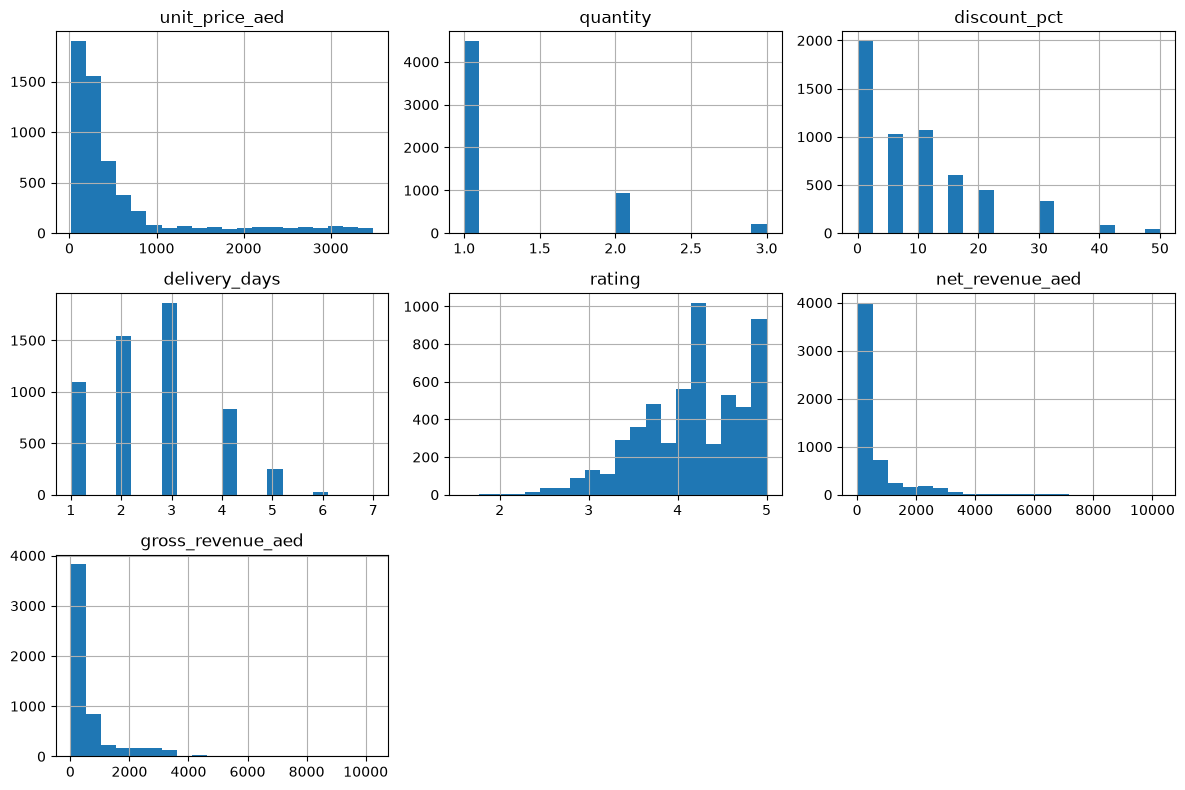

In [43]:
import matplotlib.pyplot as plt
df[['unit_price_aed','quantity','discount_pct','delivery_days','rating','net_revenue_aed','gross_revenue_aed']].hist(figsize=(12, 8), bins= 20)
plt.tight_layout()
plt.show()

## Distribution of categorical column using bar chart

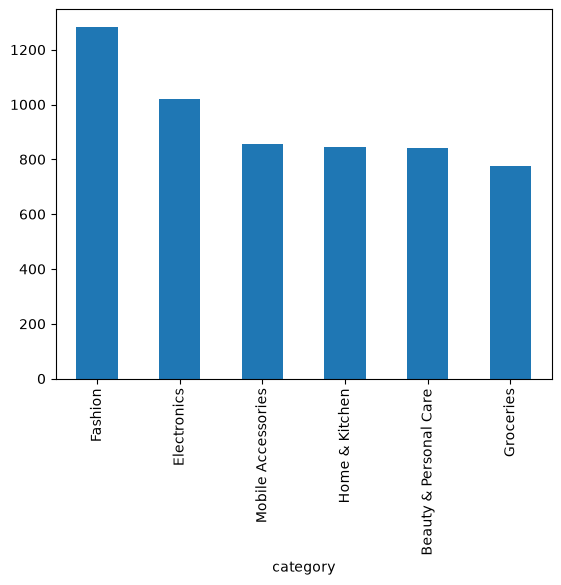

In [44]:
df['category'].value_counts().plot(kind='bar')
plt.show()

### Analyzing from which cities the orders placed

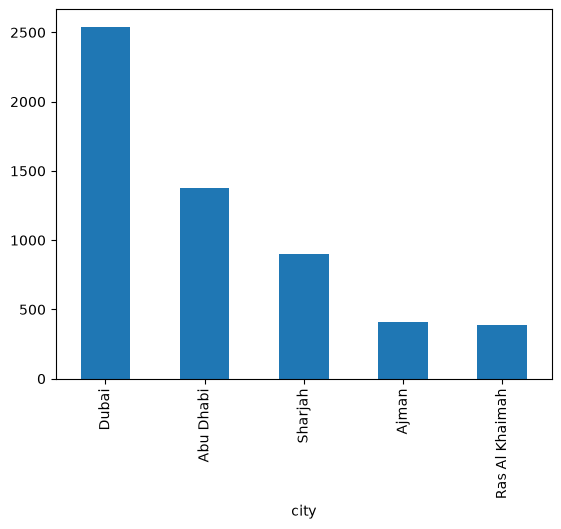

In [45]:
df['city'].value_counts().plot(kind='bar')
plt.show()

## payment method chart using bar chart

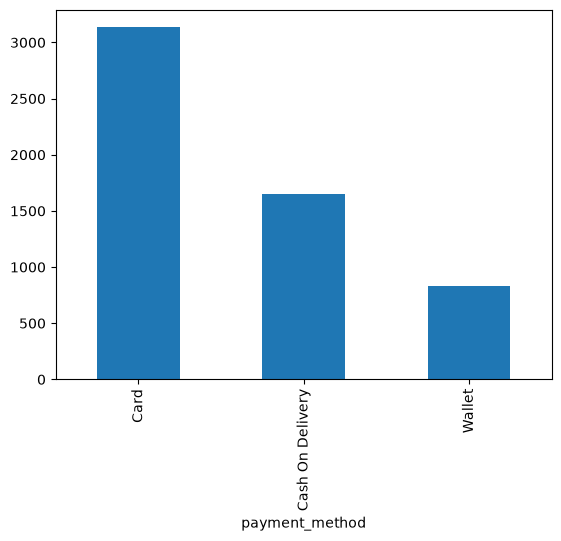

In [46]:
df['payment_method'].value_counts().plot(kind='bar')
plt.show()

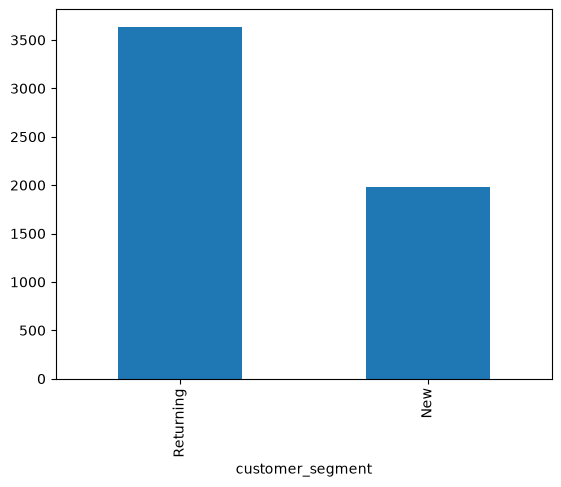

In [47]:
df['customer_segment'].value_counts().plot(kind='bar')
plt.show()

## analyzing outliers

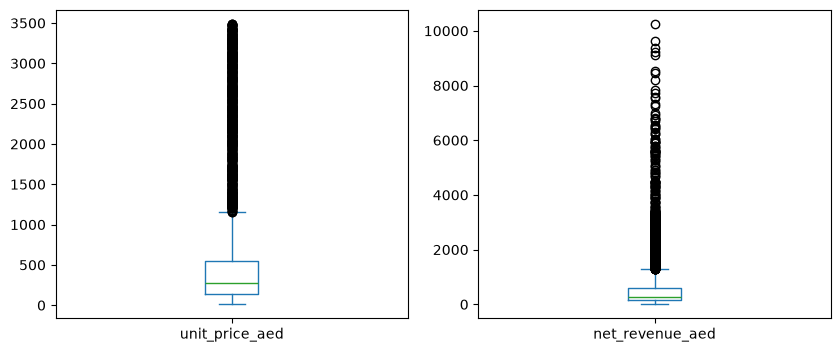

In [48]:
df[['unit_price_aed','net_revenue_aed']].plot(kind='box', subplots= True, figsize=(10, 4))
plt.show()

## verifying if the outliers are true and found they are not outliers, they are high prices electronics

In [49]:
df[df['unit_price_aed'] > 1200]

,order_id,order_date,city,category,unit_price_aed,quantity,discount_pct,gross_revenue_aed,net_revenue_aed,payment_method,customer_segment,delivery_days,rating
10,115568,2024-09-08,Sharjah,Electronics,2789.62,2,10.0,5579.24,5021.32,Cash On Delivery,Returning,2.0,4.4
11,106484,2024-04-18,Dubai,Electronics,3074.32,1,0.0,3074.32,3074.32,Cash On Delivery,Returning,1.0,4.6
30,143786,2025-10-26,Sharjah,Electronics,2707.79,1,5.0,2707.79,2572.40,Wallet,New,2.0,4.2
35,123136,2024-12-26,Dubai,Electronics,3193.41,1,10.0,3193.41,2874.07,Card,Returning,1.0,3.9
36,130683,2025-04-21,Abu Dhabi,Electronics,1667.52,2,5.0,3335.04,3168.29,Cash On Delivery,Returning,2.0,4.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6121,142348,2025-05-10,Dubai,Electronics,3417.18,3,0.0,10251.54,10251.54,Card,Returning,2.0,4.3
6131,126094,2025-10-02,Ras Al Khaimah,Electronics,2067.22,1,5.0,2067.22,1963.86,Cash On Delivery,New,2.0,5.0
6132,103077,2024-02-22,Sharjah,Electronics,3117.17,2,10.0,6234.34,5610.91,Card,New,3.0,5.0
6134,141636,2025-09-26,Abu Dhabi,Electronics,3485.18,1,10.0,3485.18,3136.66,Card,Returning,2.0,3.7


In [50]:
df[df['unit_price_aed']> 1200]['category'].value_counts()

category
Electronics    734
Name: count, dtype: int64

## price by category using box plot

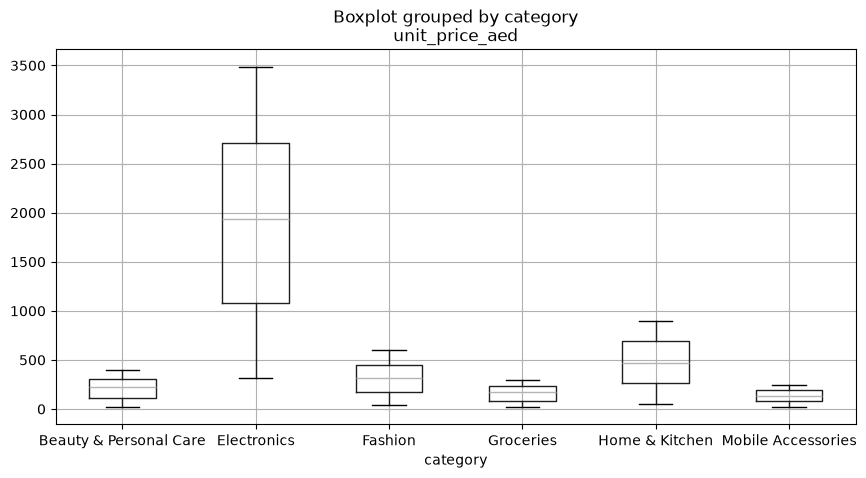

In [51]:
df.boxplot(column='unit_price_aed', by='category', figsize=(10,5))
plt.show()

## revenue by category using bar chart

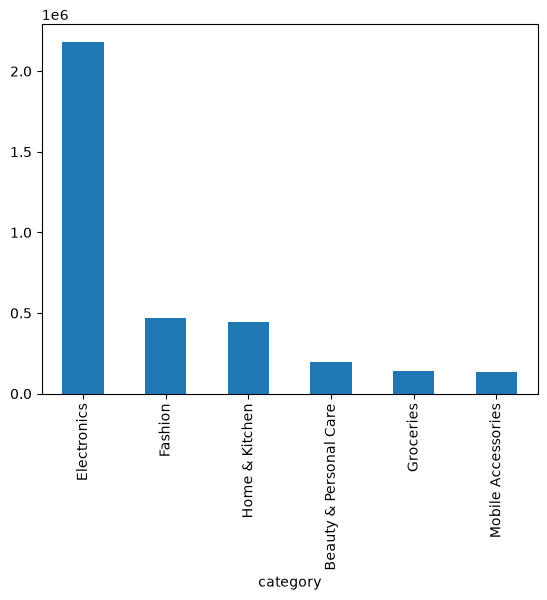

In [52]:
df.groupby('category')['net_revenue_aed'].sum().sort_values(ascending= False).plot(kind='bar')
plt.show()

## revenue by city using bar chart

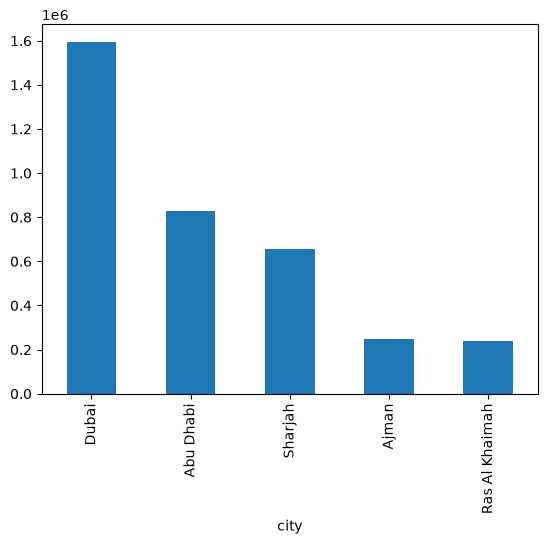

In [53]:
df.groupby('city')['net_revenue_aed'].sum().sort_values(ascending=False).plot(kind='bar')
plt.show()

In [54]:
df['order_date'].dtype

dtype('<M8[us]')

## monthly revenue trend by month and year

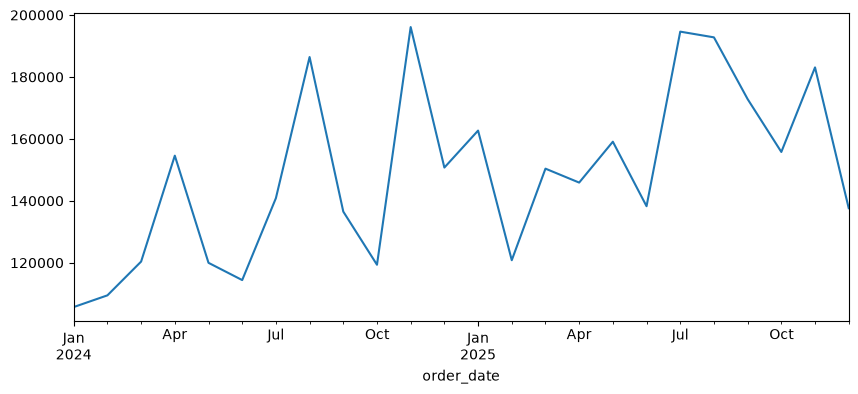

In [55]:
monthly =df.groupby(df['order_date'].dt.to_period('M'))['net_revenue_aed'].sum()
monthly.plot(figsize=(10, 4))
plt.show()

In [56]:
monthly

order_date
2024-01    105693.64
2024-02    109470.43
2024-03    120377.08
2024-04    154577.36
2024-05    119975.40
2024-06    114402.00
2024-07    140858.21
2024-08    186428.10
2024-09    136514.26
2024-10    119351.39
2024-11    196109.76
2024-12    150735.56
2025-01    162673.63
2025-02    120813.90
2025-03    150384.04
2025-04    145884.86
2025-05    159086.03
2025-06    138254.18
2025-07    194627.66
2025-08    192781.09
2025-09    172838.82
2025-10    155769.97
2025-11    183079.03
2025-12    137613.99
Freq: M, Name: net_revenue_aed, dtype: float64

## checking month with lowest revenue

In [57]:
monthly.idxmin(),monthly.min()

(Period('2024-01', 'M'), np.float64(105693.64))

## checking month with highest revenue

In [58]:
monthly.idxmax(),monthly.max()

(Period('2024-11', 'M'), np.float64(196109.76))

In [59]:
df.groupby('discount_pct')['net_revenue_aed'].mean()

discount_pct
0.0     680.729444
5.0     658.075516
10.0    643.019730
15.0    644.258581
20.0    523.521292
30.0    468.910539
40.0    476.427701
50.0    421.116000
Name: net_revenue_aed, dtype: float64

In [60]:
df.groupby('delivery_days')['rating'].mean()

delivery_days
1.0    4.148537
2.0    4.199935
3.0    4.156431
4.0    4.171685
5.0    4.178862
6.0    4.296774
7.0    4.900000
Name: rating, dtype: float64

In [61]:
df.groupby('delivery_days')['rating'].agg(['mean','count'])

,mean,count
delivery_days,,
1.0,4.148537,1094
2.0,4.199935,1543
3.0,4.156431,1866
4.0,4.171685,837
5.0,4.178862,246
6.0,4.296774,31
7.0,4.900000,2


## checking relationship between columns. Correlation table

In [62]:
df[['unit_price_aed', 'quantity', 'discount_pct', 'delivery_days', 'rating', 'net_revenue_aed']].corr()

,unit_price_aed,quantity,discount_pct,delivery_days,rating,net_revenue_aed
unit_price_aed,1.000000,0.005185,0.014159,0.007841,0.026260,0.879434
quantity,0.005185,1.000000,-0.008587,0.008448,0.002758,0.276647
discount_pct,0.014159,-0.008587,1.000000,-0.012955,-0.021097,-0.062096
delivery_days,0.007841,0.008448,-0.012955,1.000000,0.007062,0.016708
rating,0.026260,0.002758,-0.021097,0.007062,1.000000,0.026254
net_revenue_aed,0.879434,0.276647,-0.062096,0.016708,0.026254,1.000000


## which payment method generated most revenue

In [63]:
df.groupby('payment_method')['net_revenue_aed'].sum()

payment_method
Card                1987316.92
Cash On Delivery    1058297.70
Wallet               522685.77
Name: net_revenue_aed, dtype: float64

In [64]:
df.groupby('customer_segment')['net_revenue_aed'].agg(['mean', 'count'])

,mean,count
customer_segment,,
New,654.952664,1982
Returning,624.191424,3637


## key findings
- Revenue by category: Electronics generated the highest revenue followed by fashion and home and kitchen.
- Revenue by city: The largest sales are generated from Dubai.
- Revenue trend: Revenue showed upward peak over the period covered with notable spikes in november likely due to seasonal shopping or winter vacation.
- Revenue generated by payment methid: Most common payment method used is card, followed by cash on delivery and then comes the wallet.
- Data quality: after cleaning, the dataset had 0 missing values, 0 duplicates and all numerical column4s were in realistic ranges